# BEE 4750 Homework 1: Introduction to Using Julia

**Name**: Samantha Davies

**ID**: SLD238

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Teaching/BEE4750-hw/hw01-solution`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [2]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [3]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [4]:
function minimum(array)
    # initialize the minimum value counter
    min_value = 0
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 0


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

The logical flaw in the code is that it is looking for a value that is less than the initial min_value, which was set to 0. If no negative numbers are present, this will always return 0.

In [5]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 2:length(array)
        if array[i] < min_value
            min_value = array[i]

        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78



#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [6]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(student_grades)
  return average_grade
end

@show average_grade;

UndefVarError: UndefVarError: `average_grade` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

The UndefVarError means that a variable was called, but has had nothing assigned to it 

The code produces an UndefVarError because the average_grade variable is only contained within a function, then it was called outside of the function. Instead, the function class_average() should have been called with the vector student_grades inside.

In [7]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(grades)
  return average_grade
end

@show class_average(student_grades);

class_average(student_grades) = 94.4


#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [8]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zero(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

MethodError: MethodError: no method matching setindex!(::Int64, ::Bool, ::Int64)
The function `setindex!` exists, but no method is defined for this combination of argument types.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

The MethodError means we are trying to index something that cannot be indexed.

This code produces a 'MethodError' because in the for loop, we are trying to append a vector iteratively, but the 'vector' we are appending is actually an integer, so it only has one space for information.

Instead of "outcomes = zero(n_trials)", this line should be "outcomes = zeros(Int, (n_trials))" because this specifies that the value will be an integer (0 or 1).

In the for loop, "outcomes[i] = (sum(passadieci()) > 11)" should be "outcomes[i] = sum(passadieci()) > 10" because success is 11 OR greater (which is the same as greater than or equal to 10 when working with integers).

In [9]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(Int, (n_trials))
# simulate number of passadieci rolls and count wins
for i in 1:n_trials
    outcomes[i] = sum(passadieci()) > 10
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.502



#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [10]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect - m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

MethodError: MethodError: no method matching -(::Vector{Float64}, ::Float64)
For element-wise subtraction, use broadcasting with dot syntax: array .- scalar
The function `-` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  -(!Matched::Missing, ::Number)
   @ Base missing.jl:123
  -(!Matched::Complex{Bool}, ::Real)
   @ Base complex.jl:329
  -(!Matched::ChainRulesCore.NotImplemented, ::Any)
   @ ChainRulesCore ~/.julia/packages/ChainRulesCore/Vsbj9/src/tangent_arithmetic.jl:49
  ...


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

This MethodError means we tried to subtract a scaler value from a vector, which julia does not understand.

This code produces a MethodError because when we return vect - m, vect is a vector, but m is a scaler. We can use different notation to correctly subtract a scaler from a vector in Julia.

In [11]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [-0.402858193077954, 0.17163216613218168, -0.18169592947668356, 0.060514380686886415, -0.2591266252711959, -0.01737820236308285, 0.37319528099391985, 0.23362003830781186, -0.3090151132440434, -0.06824664473090836, 0.3127573063344131, -0.39730315107992675, 0.07450943943251365, 0.17821237477494634, -0.031914855823978905, 0.2901957389388936, -0.29439767231500735, -0.39428682614985444, 0.28469675398714955, -0.15391309414849141, 0.18410969908054953, 0.10996576619091203, 0.4366100026219155, 0.12668848258922027, -0.19376596222612996, 0.39947992422693535, -0.29291782437448555, 0.0258765406000393, -0.26110728751899714, -0.49303367510298224, -0.4484985564436411, 0.18580992405552932, -0.4685566065487725, 0.2636862043549746, -0.3541814667461207, 0.46525899668409465, 0.4703884817275342, 0.14350852326153452, -0.39614791770310454, -0.2798992807671117, -0.500126160487519, 0.13375959280637362, 0.37193108311289624, 0.25355217944131936, -0.2843864496790248, 0.012224016156722084

1000-element Vector{Float64}:
 -0.402858193077954
  0.17163216613218168
 -0.18169592947668356
  0.060514380686886415
 -0.2591266252711959
 -0.01737820236308285
  0.37319528099391985
  0.23362003830781186
 -0.3090151132440434
 -0.06824664473090836
  ⋮
 -0.12715199682996414
  0.3553833867930265
  0.2658817795877152
  0.3071997855512709
  0.35638130936574974
  0.15303872493357518
 -0.10958007508724765
 -0.11638803141199039
  0.4389100002859272



### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

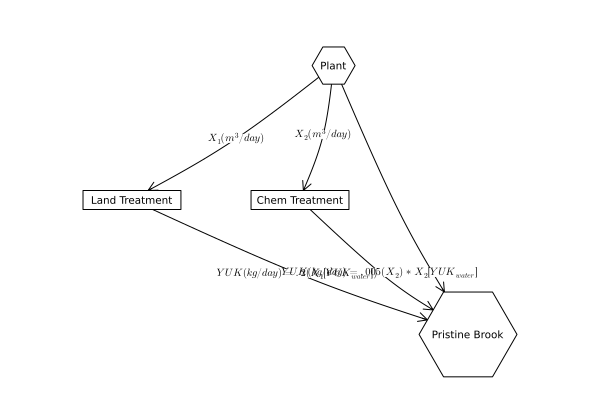

In [12]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"X_1 (m^3/day)", (1,3) => L"X_2 (m^3/day)", (1, 4) => "",(2, 4) => L"YUK (kg/day) = .2(X_1[YUK_{water}])",(3, 4) => L"YUK (kg/day) = .005(X_2)*X_2[YUK_{water}]")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).



ALL EQUATIONS:

[YUK] signifies concentration of YUK

[$YUK_{WasteWater}$] = $\frac{1 kg}{m^3}$

$X_1$ = volume water on land ($\frac{m^3}{day}$)

$X_2$ = volume water to chem plant ($\frac{m^3}{day}$)

LandCost = $\frac{(X_1)^2}{20} dollars / day$

ChemCost = $(1.50)(X_2)$ dollars / day

$YUK_{afterLandTreat}$ ($\frac{kg}{day}$) = $.2(X_1)([YUK_{WasteWater}])$

$YUK_{afterChemTreat}$ ($\frac{kg}{day}$) = $.005(X_2)(X_2)[YUK_{WasteWater}]$

$YUK_{afterLandTreat}$ + $YUK_{afterChemTreat}$ must remian $<=$ 20 $\frac{kg}{day}$

$X_1 + X_2 = 100 \frac{m^3}{day}$

TREATMENT COST = LandCost + ChemCost $\frac{dollars}{day}$


AMOUNT OF YUK DISCHARGED = $YUK_{afterLandTreat}$ + $YUK_{afterChemTreat}$ ($\frac{kg}{day}$)



#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK concentration and cost for a particular treatment plan.
You can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [13]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10


In [14]:
function conc_and_cost(x1, x2)
  #x1 and x2 are respective volunmes (in m3) of water sent to land and chem treatment in a given day 
    YUKconcentration = 1 #kg YUK per m3 wastewater
  
    YUKafterLand = .2*x1*YUKconcentration #kg YUK per day
    YUKafterChem =  .005*x2*x2*YUKconcentration #kg YUK per day
    YUK_concentration = YUKafterLand + YUKafterChem #kg YUK per day
   
    landCost = (x1*x1) / 20 #dollars per day
    chemCost = 1.5 * x2 #dollars per day
    cost = landCost + chemCost #dollars per day

    return (YUK_concentration, cost)
end

YUK_concentration, cost = conc_and_cost(70, 30)
@show YUK_concentration;
@show cost;

YUK_concentration = 18.5
cost = 290.0


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [15]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


In [16]:
x1 = [90, 70, 30, 20, 5]
x2 = [10, 30, 70, 80, 95]

output = conc_and_cost.(x1, x2)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [18.5, 18.5, 30.500000000000004, 36.0, 46.125]
b = [420.0, 290.0, 150.0, 140.0, 143.75]


Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK concentration? You don’t have to find an
“optimal” solution to this problem, but what do you think would be
needed to find a better solution?



YUK_concentration = [18.0474283813383, 30.138575233978337, 18.191147132725597, 48.48437965560738, 19.5518262029045, 33.151512356190246, 34.41096069425338, 18.176616666491437, 34.090615537491324, 18.403751577977392, 30.757129017245347, 20.111842782422194, 38.381589720246694, 31.25751180460987, 18.5778402395923, 38.50749404861545, 18.375397098930122, 46.31553761506556, 19.702641844481292, 18.73173452467358, 18.52680962679625, 18.08729661336046, 25.59837463176696, 35.933950800064274, 48.44494925759483, 19.8969711548204, 32.54100431005453, 18.39475476219776, 23.78272061040144, 23.548555700987365, 19.62975447950393, 35.42752072022124, 28.79695578001452, 18.32516559151328, 18.276017423346257, 38.81623268942653, 31.916864043562985, 31.07588457970418, 18.527204113287898, 18.2560386861383, 18.087040473046265, 34.063916620906646, 49.30511325829149, 18.6474269777131, 18.02814915085694, 20.60392286593332, 28.067996033525386, 19.14174321800991, 21.140496280478636, 43.9432651335183, 18.2646267307920

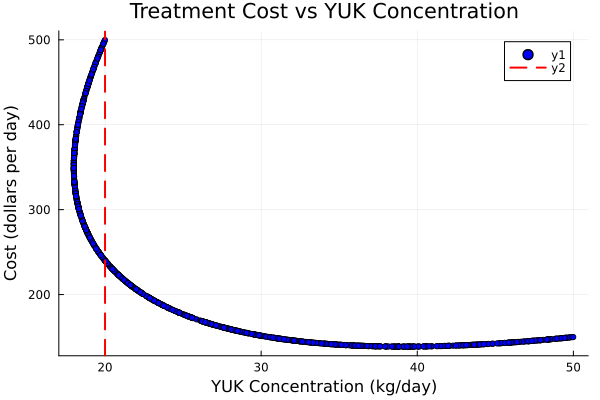

In [17]:
Values = rand(Dirichlet([1.0,1.0]), 1000)

Values_scaled = Values .*100

x1 = Values_scaled[1, :]
x2 = Values_scaled[2, :]


output = conc_and_cost.(x1, x2)
YUK_concentration = [out[1] for out in output]
cost = [out[2] for out in output]
@show YUK_concentration;
@show cost;



scatter(YUK_concentration, cost,
        xlabel="YUK Concentration (kg/day)",
        ylabel="Cost (dollars per day)",
        title="Treatment Cost vs YUK Concentration",
        markercolor=:blue,
        markersize=3)
        vline!([20], color=:red, linestyle=:dash, linewidth=2)

The cost of solutions that keep YUK below 20kg/day is at a minimum, around $220. Concentrations can be made even lower if we spend up to ~$350.

For most of the graph, as concentration is allowed to be higher, treatment cost decreases.

A better solution to this problem could be found by determining a cost-benefit analysis and finding a sweet spot between price and concentration below 20. This may require knowing how much benefit an ecosystem would see from x decrease in YUK, and what the budget of the dischargers looks like.



#### Problem 2.4

Find the strategies which minimize cost and YUK concentration (these
will be different strategies) analytically and find the values of the
objective metrics. Plot these values in the plot that you created for
Problem 3.3. How do their values compare to the spread of values that
you found in that problem? Would you select either of them (explain why
or why not)?


Strategies that minimize cost

In [18]:
# Find the index of the value closest to 20
index = argmin(abs.(YUK_concentration .- 20))

concentration_costmin = YUK_concentration[index]

# Get the corresponding cost
corresponding_cost_costmin = cost[index]

# how much water was treated by land when minimizing cost
x1_value = x1[index]
#How much water was treated by chem plant when minimizing cost
x2_value = x2[index]

@show concentration_costmin; 

@show corresponding_cost_costmin; #lowest cost


@show x1_value; #water treated on land (m^3 / day)
@show x2_value; #water treated at plant (m^3 / day)

concentration_costmin = 19.99285119487733
corresponding_cost_costmin = 499.69596779465707
x1_value = 99.96422397628982
x2_value = 0.03577602371018476


Strategies that minimize YUK

In [19]:
# Find the index of the lowest YUK value
index = argmin(YUK_concentration)

concentration_YUKmin = YUK_concentration[index]


# Get the corresponding cost
corresponding_cost_YUKmin = cost[index]

# how much water was treated by land when minimizing YUK
x1_value = x1[index]
#How much water was treated by chem plant when minimizing YUK
x2_value = x2[index]

@show concentration_YUKmin; #lowest possible

@show corresponding_cost_YUKmin; #lowest YUK


@show x1_value; #water treated on land (m^3 / day)
@show x2_value; #water treated at plant (m^3 / day)

concentration_YUKmin = 18.00000057884455
corresponding_cost_YUKmin = 350.0699431636311
x1_value = 80.0107595961824
x2_value = 19.989240403817597


I would want to choose the strategy that minimizes YUK, because it doesn't seem to cost THAT much more money to do so, and it is better for the environment.

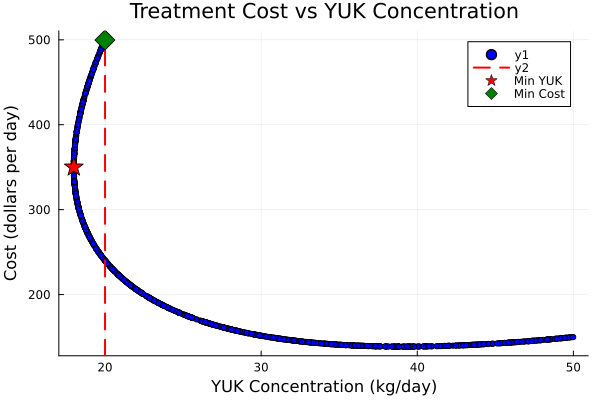

In [20]:
scatter(YUK_concentration, cost,
        xlabel="YUK Concentration (kg/day)",
        ylabel="Cost (dollars per day)",
        title="Treatment Cost vs YUK Concentration",
        markercolor=:blue,
        markersize=3)
        vline!([20], color=:red, linestyle=:dash, linewidth=2)
        scatter!([concentration_YUKmin], [corresponding_cost_YUKmin], color=:red, marker=:star5, markersize=10, label="Min YUK")
        scatter!([concentration_costmin], [corresponding_cost_costmin], color=:green, marker=:diamond, markersize=10, label="Min Cost")


## References

List any external references consulted, including classmates.

